#### Imports, constants and helpers

In [1]:
# %% Imports, constants and helpers

import json
from pathlib import Path
import sqlite3
from typing import List

import matplotlib.pylab as plt
import numpy as np
import pandas as pd

RESULTS_DIR = Path(
    "/home/marvin/workspace/guut-evaluation/03_cosmic_ray_v0.3/string_utils_365285bb_baseline/loops"
)
SESSION_FILE = Path(
    "/home/marvin/workspace/guut-evaluation/03_cosmic_ray_v0.3/string_utils_365285bb_baseline/mutants.sqlite"
)

pd.set_option("display.width", 120)

#### Load json files

In [2]:
# %% Load json files

results_json = []
for root, dirs, files in RESULTS_DIR.walk():
    result_paths = (root / name for name in files if name == "result.json")
    for path in result_paths:
        result = json.loads(path.read_text())
        if "baseline" in str(root):
            result["implementation"] = "baseline"
        else:
            result["implementation"] = "loop"
        results_json.append(result)

# Sort!
results_json.sort(key=lambda result: result["timestamp"])

data = pd.json_normalize(results_json)

#### Load mutants

In [3]:
# %% Load mutants

con = sqlite3.connect(SESSION_FILE)
cur = con.cursor()
cur.execute(
    "select module_path, operator_name, occurrence, start_pos_row, end_pos_row from mutation_specs;"
)
mutants = cur.fetchall()

#### Load mutant line info into the table

In [4]:
# %% Load mutant line info into the table

mutant_lines = {(m[0], m[1], m[2]): (m[3], m[4]) for m in mutants}
data["mutant_lines"] = data.apply(
    lambda row: mutant_lines[
        (
            row["problem.target_path"],
            row["problem.mutant_op"],
            row["problem.occurrence"],
        )
    ],
    axis=1,
)
data["mutant_lines.start"] = data["mutant_lines"].map(lambda t: t[0])
data["mutant_lines.end"] = data["mutant_lines"].map(lambda t: t[1])


# Check whether each run covers the mutant


def experiment_covers_mutant(row):
    start, end = row["mutant_lines"]
    mutant_lines = set(range(start, end + 1))
    experiments = row["experiments"]
    return any(
        set(exp["result"]["test"]["coverage"]["covered_lines"]).intersection(
            mutant_lines
        )
        for exp in experiments
        if exp["result"] and exp["result"]["test"]["coverage"]
    )


def test_covers_mutant(row):
    start, end = row["mutant_lines"]
    mutant_lines = set(range(start, end + 1))
    tests = row["tests"]
    return any(
        set(test["result"]["correct"]["coverage"]["covered_lines"]).intersection(
            mutant_lines
        )
        for test in tests
        if test["result"] and test["result"]["correct"]["coverage"]
    )


data["experiment_covers_mutant"] = data.apply(experiment_covers_mutant, axis=1)
data["test_covers_mutant"] = data.apply(test_covers_mutant, axis=1)
data["mutant_covered"] = data["experiment_covers_mutant"] | data["test_covers_mutant"]

#### Compute coverage

In [5]:
# %% Compute coverage


def find_killing_test(tests):
    killing_tests = [test for test in tests if test["kills_mutant"]]
    return killing_tests[0] if killing_tests else None


def get_coverage_from_test(test):
    if test is None:
        return [], []
    test_result = test.get("result")
    if test_result is None:
        return [], []
    coverage = test_result["correct"].get("coverage")
    if coverage is None:
        return [], []
    return coverage["covered_lines"], coverage["missing_lines"]


data["coverage.covered_lines"] = data["tests"].map(
    lambda tests: get_coverage_from_test(find_killing_test(tests))[0]
)
data["coverage.missing_lines"] = data["tests"].map(
    lambda tests: get_coverage_from_test(find_killing_test(tests))[1]
)


def add_coverage(x: List[int], y: List[int]) -> List[int]:
    acc = set(x)
    acc.update(y)
    return list(acc)

#### Plot Coverage

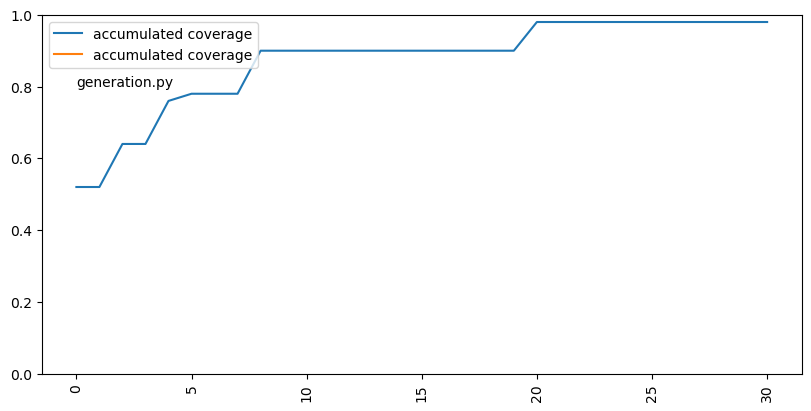

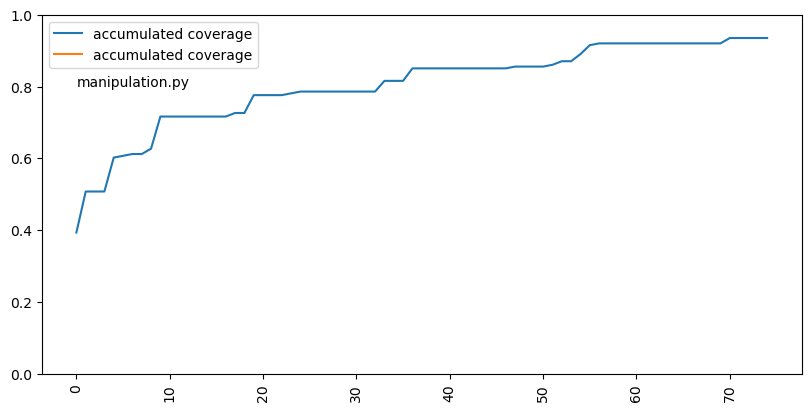

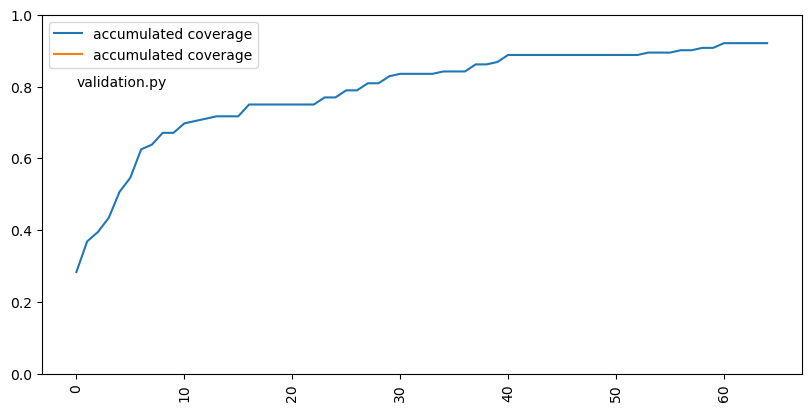

In [6]:
# %% Plot Coverage

add_coverage = np.frompyfunc(add_coverage, 2, 1)

for target_path in np.unique(data[["problem.target_path"]]):
    target_data = data[data["problem.target_path"] == target_path]
    all_lines = set(target_data.iloc[0]["coverage.covered_lines"])
    all_lines.update(target_data.iloc[0]["coverage.missing_lines"])

    if not all_lines:
        continue

    acc_coverage = add_coverage.accumulate(target_data["coverage.covered_lines"])
    acc_coverage_percent = acc_coverage.map(lambda c: len(c) / len(all_lines))

    x = np.arange(len(acc_coverage))
    fig, ax = plt.subplots(layout="constrained", figsize=(8, 4))
    ax.set_ylim(0, 1)
    ax.plot(x, acc_coverage_percent, 0.6, label="accumulated coverage")
    ax.tick_params(axis="x", rotation=90)
    ax.legend(loc="upper left")
    ax.text(0, 0.8, target_path)
    plt.show()

#### Plot number of killed mutants

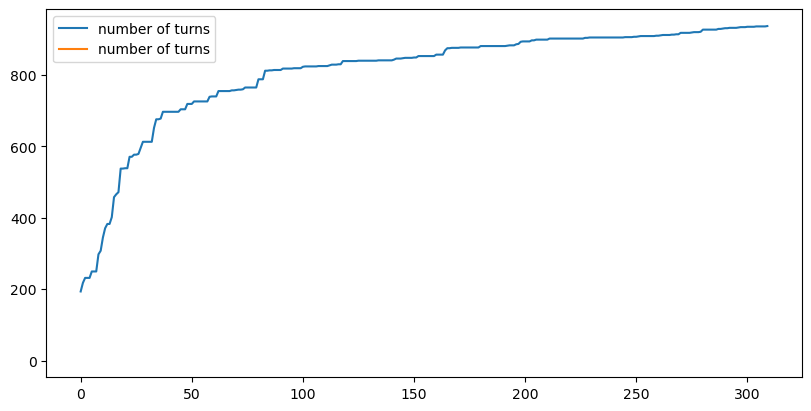

In [7]:
# %% Plot number of killed mutants

killed_mutants = data["killed_mutants"].map(len)

x = np.arange(len(data))
fig, ax = plt.subplots(layout="constrained", figsize=(8, 4))
ax.plot(x, np.cumsum(killed_mutants), 0.6, label="number of turns")
ax.legend(loc="upper left")
plt.show()

#### Compute Token Usage

In [8]:
# %% Compute Token Usage

data["usage.prompt_tokens"] = data["conversation"].map(
    lambda c: sum(
        msg["usage"]["prompt_tokens"] for msg in c if msg["role"] == "assistant"
    )
)
data["usage.completion_tokens"] = data["conversation"].map(
    lambda c: sum(
        msg["usage"]["completion_tokens"] for msg in c if msg["role"] == "assistant"
    )
)
data["usage.total_tokens"] = (
    data["usage.prompt_tokens"] + data["usage.completion_tokens"]
)

# Add cost in $ for gpt4o-mini
# prompt: $0.150 / 1M input tokens
# completion: $0.600 / 1M input tokens
data["usage.cost"] = (data["usage.prompt_tokens"] * 0.150 / 1_000_000) + (
    data["usage.completion_tokens"] * 0.600 / 1_000_000
)

#### Token usage mean

In [9]:
# %% Token usage mean

data.groupby("implementation")[
    ["usage.prompt_tokens", "usage.completion_tokens", "usage.cost"]
].mean()

,usage.prompt_tokens,usage.completion_tokens,usage.cost
implementation,,,
baseline,122215.035484,8124.193548,0.023207


#### Token usage sum

In [10]:
# %% Token usage sum

data.groupby("implementation")[
    ["usage.prompt_tokens", "usage.completion_tokens", "usage.cost"]
].sum()

,usage.prompt_tokens,usage.completion_tokens,usage.cost
implementation,,,
baseline,37886661,2518500,7.194099


#### Count messages, experiments, tests

In [11]:
# %% Count messages, experiments, tests

data["num_turns"] = data["conversation"].map(
    lambda conv: len([msg for msg in conv if msg["role"] == "assistant"])
)
data["num_experiments"] = data["experiments"].map(
    lambda exps: len([exp for exp in exps if exp["kind"] == "experiment"])
)
data["num_tests"] = data["tests"].map(len)
data["num_invalid_experiments"] = data["experiments"].map(
    lambda exps: len(
        [
            exp
            for exp in exps
            if exp["kind"] == "experiment" and not exp["validation_result"]["valid"]
        ]
    )
)
data["num_invalid_tests"] = data["tests"].map(
    lambda tests: len(
        [test for test in tests if not test["validation_result"]["valid"]]
    )
)

#### Count message types

In [12]:
# %% Count message types

relevant_msg_tags = [
    "experiment_stated",
    "experiment_doesnt_compile",
    "experiment_results_given",
    "test_instructions_given",
    "test_stated",
    "test_invalid",
    "test_doesnt_detect_mutant",
    "claimed_equivalent",
    "done",
    "incomplete_response",
    "aborted",
]

for tag in relevant_msg_tags:
    data[f"tag.{tag}"] = data["conversation"].map(
        lambda conv: len([msg for msg in conv if msg["tag"] == tag])
    )

#### Compute test LOC

In [13]:
# %% Compute test LOC


def estimate_loc(test):
    if test is None:
        return None
    return len(
        [
            line
            for line in test["code"].splitlines()
            if line.strip() and not line.strip().startswith("#")
        ]
    )


data["test_loc"] = data["tests"].map(
    lambda tests: estimate_loc(find_killing_test(tests))
)

#### Compute number of import errors

In [14]:
# %% Compute number of import errors


def count_import_errors(exps_or_tests):
    return len(
        [
            exp
            for exp in exps_or_tests
            if exp["result"]
            and "ModuleNotFoundError"
            in (exp["result"].get("correct") or exp["result"].get("test"))["output"]
        ]
    )


data["num_experiment_import_errors"] = data["experiments"].map(count_import_errors)
data["num_test_import_errors"] = data["tests"].map(count_import_errors)

#### Count number of debugger scripts

In [15]:
# %% Count number of debugger scripts

data["num_debugger_scripts"] = data["experiments"].map(
    lambda exps: len([exp for exp in exps if exp["debugger_script"]])
)

#### Percentage of experiments with debugger scripts

In [16]:
# %% Percentage of experiments with debugger scripts

loop_data = data[data["implementation"] == "loop"]
loop_data["num_debugger_scripts"].sum() / loop_data["num_experiments"].sum()

/tmp/ipykernel_69113/4260093022.py:4: RuntimeWarning: invalid value encountered in scalar divide
  loop_data["num_debugger_scripts"].sum() / loop_data["num_experiments"].sum()


np.float64(nan)

#### Number of turns

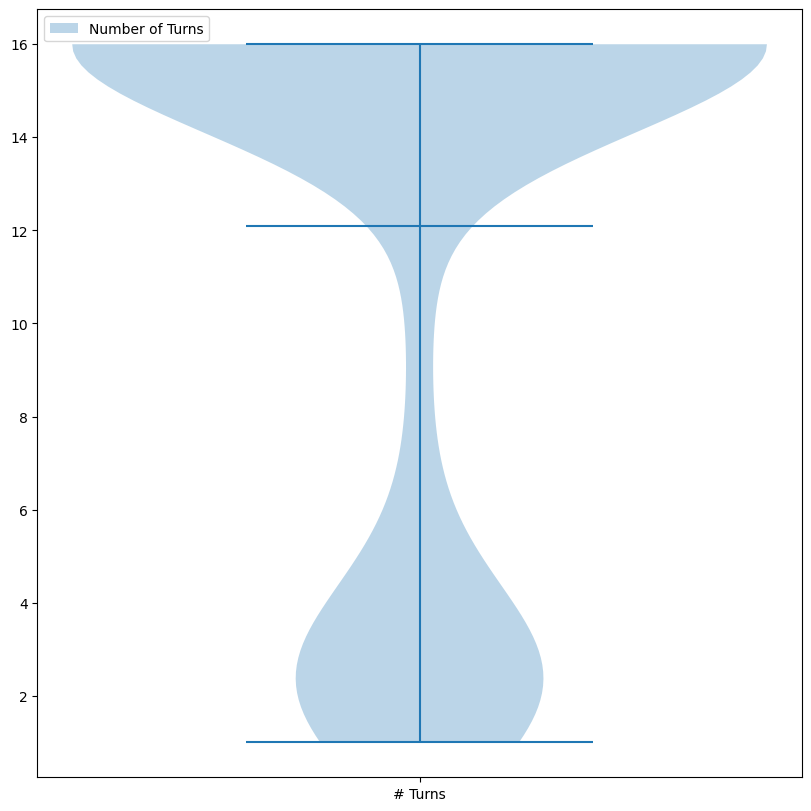

In [17]:
# %% Number of turns

fig, ax = plt.subplots(layout="constrained", figsize=(8, 8))
ax.set_xticks([1])
ax.set_xticklabels(["# Turns"])
ax.violinplot(data["num_turns"], showmeans=True)
ax.legend(["Number of Turns"], loc="upper left")
plt.show()

#### Number of turns per successful / unsuccessful run

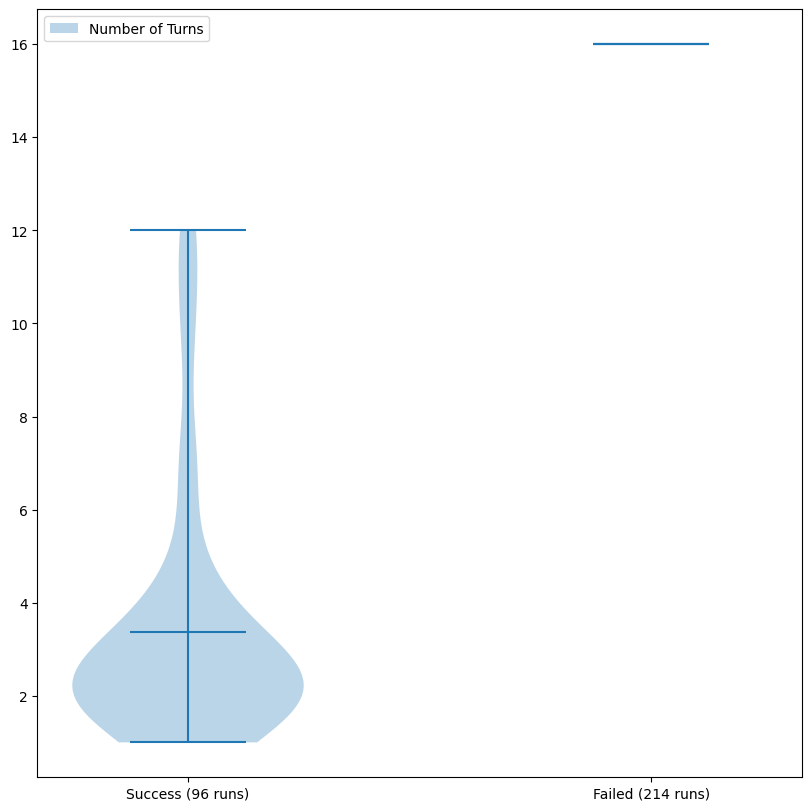

In [18]:
# %% Number of turns per successful / unsuccessful run

turns_success = data["num_turns"][data["mutant_killed"]]
turns_equivalent = data["num_turns"][data["claimed_equivalent"]]
turns_fail = data["num_turns"][(~data["mutant_killed"]) & (~data["claimed_equivalent"])]

fig, ax = plt.subplots(layout="constrained", figsize=(8, 8))
ax.set_xticks([1, 2])
ax.set_xticklabels(
    [
        f"Success ({len(turns_success)} runs)",
        f"Failed ({len(turns_fail)} runs)",
    ]
)
ax.violinplot(
    [
        turns_success,
        turns_fail,
    ],
    showmeans=True,
)
ax.legend(["Number of Turns"], loc="upper left")
plt.show()

#### Number of turns

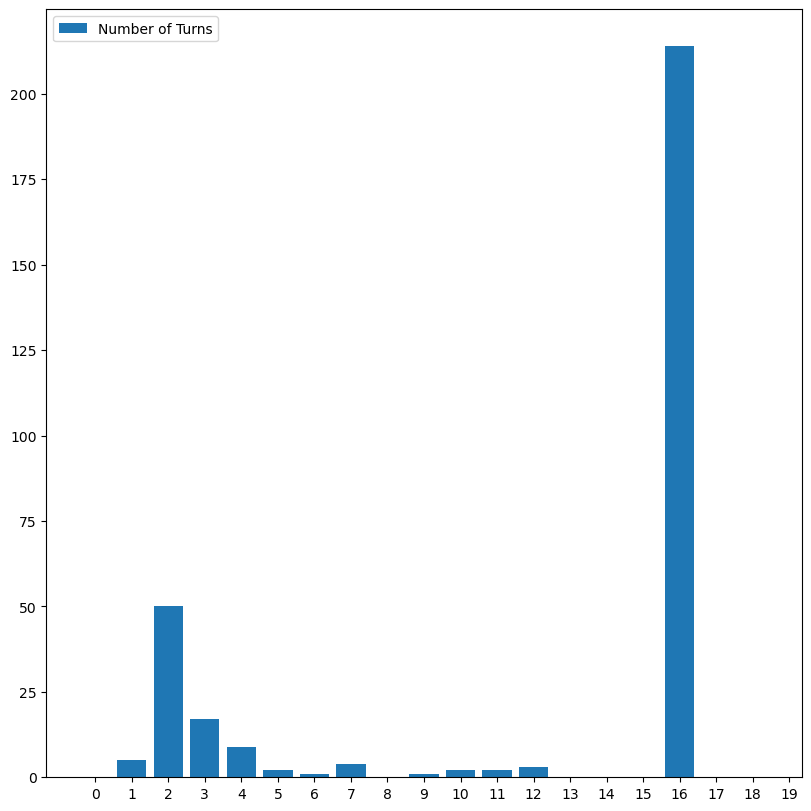

In [19]:
# %% Number of turns

fig, ax = plt.subplots(layout="constrained", figsize=(8, 8))
ax.set_xticks(x)
ax.hist(
    data["num_turns"],
    bins=np.arange(20) - 0.5,
    rwidth=0.8,
)
ax.legend(["Number of Turns"], loc="upper left")
plt.show()

#### Number of turns per successful / unsuccessful run

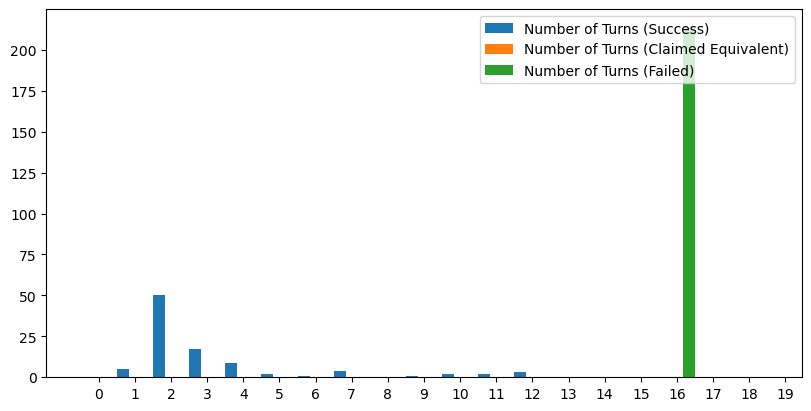

In [20]:
# %% Number of turns per successful / unsuccessful run

turns_success = data["num_turns"][data["mutant_killed"]]
turns_equivalent = data["num_turns"][data["claimed_equivalent"]]
turns_fail = data["num_turns"][(~data["mutant_killed"]) & (~data["claimed_equivalent"])]

fig, ax = plt.subplots(layout="constrained", figsize=(8, 4))
ax.set_xticks(x)
ax.hist(
    [turns_success, turns_equivalent, turns_fail],
    bins=np.arange(20) - 0.5,
    rwidth=1,
)
ax.legend(
    [
        "Number of Turns (Success)",
        "Number of Turns (Claimed Equivalent)",
        "Number of Turns (Failed)",
    ],
    loc="upper right",
)
plt.show()

#### Number of turns

In [21]:
# %% Number of turns

data["num_turns"].mean()

np.float64(12.087096774193549)

#### Mutants with max turns

In [22]:
# %% Mutants with max turns

data[data["num_turns"] == 16][
    ["implementation", "problem.target_path", "problem.mutant_op", "problem.occurrence"]
]

,implementation,problem.target_path,problem.mutant_op,problem.occurrence
3,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_LShift,0
4,baseline,manipulation.py,core/ReplaceComparisonOperator_Eq_Lt,2
6,baseline,generation.py,core/ReplaceComparisonOperator_Gt_NotEq,2
7,baseline,manipulation.py,core/AddNot,19
13,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_BitXor,0
...,...,...,...,...
303,baseline,validation.py,core/ReplaceUnaryOperator_USub_Invert,0
305,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_Div,12
306,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_BitXor,11
307,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_Pow,6


#### Number of experiments / tests per task

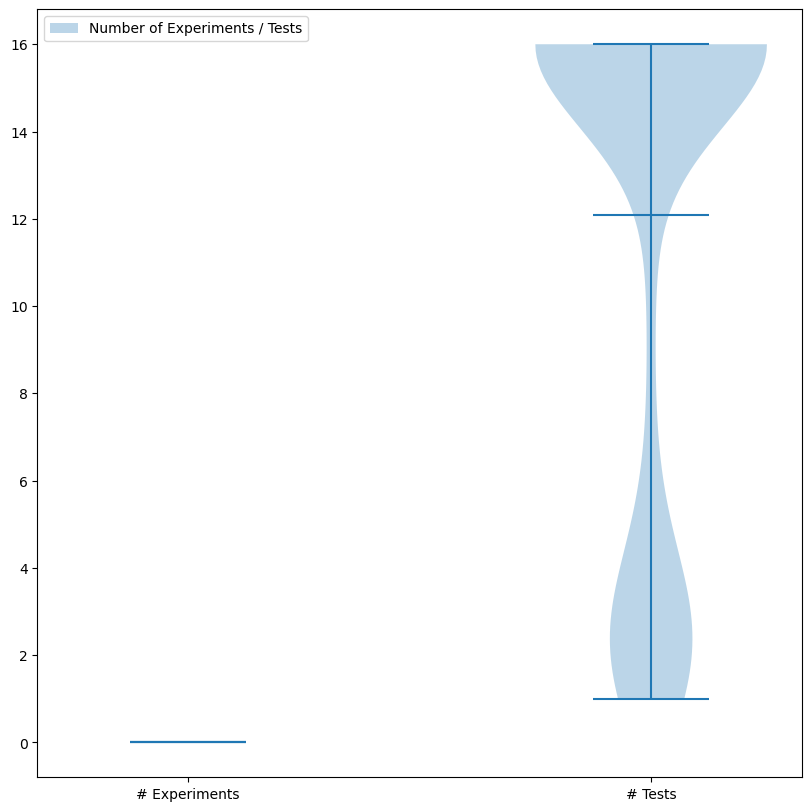

In [23]:
# %% Number of experiments / tests per task

x = np.arange(len(data))
fig, ax = plt.subplots(layout="constrained", figsize=(8, 8))
ax.violinplot(
    [data["num_experiments"], data["num_tests"]], positions=[1, 2], showmeans=True
)
ax.set_xticks([1, 2])
ax.set_xticklabels(["# Experiments", "# Tests"])
ax.legend(["Number of Experiments / Tests"], loc="upper left")
plt.show()
plt.show()

#### Success rate

In [24]:
# %% Success rate

data.groupby("implementation")[["mutant_killed"]].sum() / data.groupby(
    "implementation"
)[["mutant_killed"]].count()

,mutant_killed
implementation,
baseline,0.309677


#### Unkilled mutants

In [25]:
# %% Unkilled mutants

data[data["mutant_killed"] == 0][
    ["implementation", "problem.target_path", "problem.mutant_op", "problem.occurrence"]
]

,implementation,problem.target_path,problem.mutant_op,problem.occurrence
3,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_LShift,0
4,baseline,manipulation.py,core/ReplaceComparisonOperator_Eq_Lt,2
6,baseline,generation.py,core/ReplaceComparisonOperator_Gt_NotEq,2
7,baseline,manipulation.py,core/AddNot,19
13,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_BitXor,0
...,...,...,...,...
303,baseline,validation.py,core/ReplaceUnaryOperator_USub_Invert,0
305,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_Div,12
306,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_BitXor,11
307,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_Pow,6


#### Mean test LOC

In [26]:
# %% Mean test LOC

data.groupby("implementation")[["test_loc"]].mean()

,test_loc
implementation,
baseline,12.75


#### Conversations with unparsable messages

In [27]:
# %% Conversations with unparsable messages

data[data["tag.incomplete_response"] > 0][
    ["implementation", "problem.target_path", "problem.mutant_op", "problem.occurrence"]
]

,implementation,problem.target_path,problem.mutant_op,problem.occurrence


#### Aborted conversations

In [28]:
# %% Aborted conversations

data[data["tag.aborted"] > 0][
    ["implementation", "problem.target_path", "problem.mutant_op", "problem.occurrence"]
]

,implementation,problem.target_path,problem.mutant_op,problem.occurrence
3,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_LShift,0
4,baseline,manipulation.py,core/ReplaceComparisonOperator_Eq_Lt,2
6,baseline,generation.py,core/ReplaceComparisonOperator_Gt_NotEq,2
7,baseline,manipulation.py,core/AddNot,19
13,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_BitXor,0
...,...,...,...,...
303,baseline,validation.py,core/ReplaceUnaryOperator_USub_Invert,0
305,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_Div,12
306,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_BitXor,11
307,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_Pow,6


#### Equivalence claims

In [29]:
# %% Equivalence claims

data[data["tag.claimed_equivalent"] > 0][
    ["implementation", "problem.target_path", "problem.mutant_op", "problem.occurrence"]
]

,implementation,problem.target_path,problem.mutant_op,problem.occurrence


#### Non compilable experiments / tests

In [30]:
# %% Non compilable experiments / tests

data.groupby("implementation")[["num_invalid_experiments", "num_invalid_tests"]].sum()

,num_invalid_experiments,num_invalid_tests
implementation,,
baseline,0,31


#### Tasks with import errors

In [31]:
# %% Tasks with import errors

data[(data["num_experiment_import_errors"] + data["num_test_import_errors"]) > 0][
    ["implementation", "problem.target_path", "problem.mutant_op", "problem.occurrence"]
]

,implementation,problem.target_path,problem.mutant_op,problem.occurrence
0,baseline,manipulation.py,core/ReplaceBinaryOperator_Sub_BitOr,0
2,baseline,validation.py,core/ReplaceComparisonOperator_IsNot_Is,5
3,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_LShift,0
4,baseline,manipulation.py,core/ReplaceComparisonOperator_Eq_Lt,2
5,baseline,generation.py,core/ReplaceComparisonOperator_Gt_Eq,1
...,...,...,...,...
304,baseline,manipulation.py,core/NumberReplacer,8
305,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_Div,12
307,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_Pow,6
308,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_RShift,5


#### Number of directly and indirectly killed mutants

In [32]:
# %% Number of directly and indirectly killed mutants

num_mutants = len(mutants)
total_kills = data["killed_mutants"].map(len).sum()
direct_kills = len(data[data["mutant_killed"]])
indirect_kills = total_kills - direct_kills

print(f"Total mutants: {num_mutants}")
print(f"Total mutant kills: {total_kills}")
print(f"Direct mutant kills: {direct_kills}")
print(f"Indirect mutant kills: {indirect_kills}")
print(f"Alive mutants: {num_mutants - total_kills}")

Total mutants: 1122
Total mutant kills: 937
Direct mutant kills: 96
Indirect mutant kills: 841
Alive mutants: 185


#### Cost per killed mutant

In [33]:
# %% Cost per killed mutant

data["usage.cost"].sum() / total_kills

np.float64(0.007677800586979722)

#### Compute outcome for simplicity

In [34]:
# %% Compute outcome for simplicity


SUCCESS = "success"
EQUIVALENT = "equivalent"
FAIL = "fail"


def get_outcome(row):
    if row["mutant_killed"]:
        return SUCCESS
    elif row["claimed_equivalent"]:
        return EQUIVALENT
    else:
        return FAIL


data["outcome"] = data.apply(get_outcome, axis=1).to_frame(name="outcome")

#### Number of runs peere outcome

In [35]:
# %% Number of runs peere outcome

print(f"Total runs: {len(data)}")
print(f"Successful runs: {len(data[data["outcome"] == "success"])}")
print(f"Equivalent runs: {len(data[data["outcome"] == "equivalent"])}")
print(f"Failed runs: {len(data[data["outcome"] == "fail"])}")

print(f"Total runs that cover the mutant: {len(data[data["mutant_covered"]])}")
print(
    f"Successful runs that cover the mutant: {len(data[(data["outcome"] == SUCCESS) & data["mutant_covered"]])}"
)
print(
    f"Equivalent runs that cover the mutant: {len(data[(data["outcome"] == EQUIVALENT) & data["mutant_covered"]])}"
)
print(
    f"Failed runs that cover the mutant: {len(data[(data["outcome"] == FAIL) & data["mutant_covered"]])}"
)

Total runs: 310
Successful runs: 96
Equivalent runs: 0
Failed runs: 214
Total runs that cover the mutant: 160
Successful runs that cover the mutant: 67
Equivalent runs that cover the mutant: 0
Failed runs that cover the mutant: 93


#### Successful runs that don't cover the mutant?

In [36]:
# %% Successful runs that don't cover the mutant?

data[(data["outcome"] == "success") & (~data["mutant_covered"])][
    ["implementation", "problem.target_path", "problem.mutant_op", "problem.occurrence"]
]

,implementation,problem.target_path,problem.mutant_op,problem.occurrence
59,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_Sub,5
68,baseline,manipulation.py,core/NumberReplacer,5
70,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_Pow,8
71,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_Div,8
73,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_Sub,7
85,baseline,manipulation.py,core/NumberReplacer,11
87,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_Div,10
96,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_Pow,4
101,baseline,manipulation.py,core/NumberReplacer,1
107,baseline,_regex.py,core/ReplaceBinaryOperator_BitOr_Sub,12


#### Number of runs

In [37]:
# %% Number of runs

import plotly.express as px

data["color"] = data["mutant_covered"].map(lambda b: "green" if b else "red")
fig = px.parallel_categories(data, ["outcome", "mutant_covered"], color="color")
fig.show()

ModuleNotFoundError: No module named 'plotly'